# Level 1 – Unemployment Analysis in India


## Task 1- Dataset Loading and Inspection

import pandas as pd

df = pd.read_csv(r"C:\Users\harsh\Downloads\archive\Unemployment_Rate_upto_11_2020.csv")
df.head()

## Understanding Dataset Structure

In [5]:
df.shape




(267, 9)

In [6]:
df.columns


Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

### Data Cleaning and Type Conversion

In [13]:
df.columns = df.columns.str.strip()





In [31]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.dtypes



Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Region.1                                           object
longitude                                         float64
latitude                                          float64
dtype: object

### Missing Values Check

In [15]:
df.isnull().sum()



Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

## Task 2 – State-wise Unemployment Analysis


In [29]:
state_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

state_avg.head(10)


Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64

## Task 3 – Visualization of Top 10 States by Unemployment Rate



In [18]:

import matplotlib.pyplot as plt


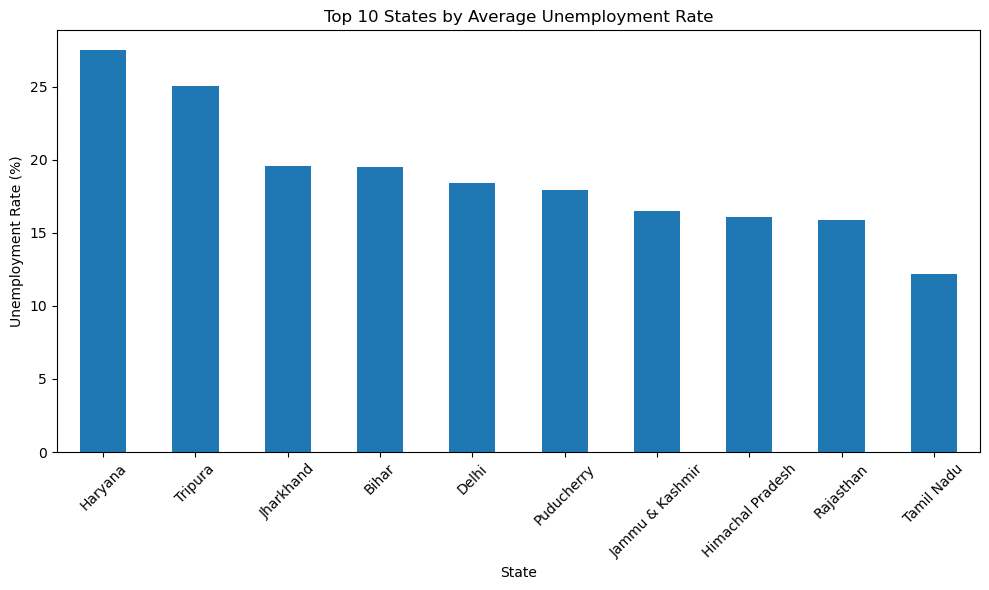

In [19]:
top10 = state_avg.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='bar')
plt.title("Top 10 States by Average Unemployment Rate")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Impact of Covid-19 on Umemployment Rate

In [32]:
# Create Year and Month columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Compare average unemployment before and during Covid (2020)
before_covid = df[df['Year'] < 2020]['Estimated Unemployment Rate (%)'].mean()
during_covid = df[df['Year'] == 2020]['Estimated Unemployment Rate (%)'].mean()

before_covid, during_covid


(nan, np.float64(12.236928838951311))

In [33]:
# Mark covid and non-covid months inside 2020
covid_period = df[(df['Year'] == 2020) & (df['Month'] >= 3)]
pre_covid_2020 = df[(df['Year'] == 2020) & (df['Month'] < 3)]

pre_covid_2020['Estimated Unemployment Rate (%)'].mean(), \
covid_period['Estimated Unemployment Rate (%)'].mean()


(np.float64(9.231346153846154), np.float64(12.963860465116278))

# Mark covid and non-covid months inside 2020
covid_period = df[(df['Year'] == 2020) & (df['Month'] >= 3)]
pre_covid_2020 = df[(df['Year'] == 2020) & (df['Month'] < 3)]

pre_covid_2020['Estimated Unemployment Rate (%)'].mean(), \
covid_period['Estimated Unemployment Rate (%)'].mean()


### Seasonal Trends in Unemployment Rate

<Axes: title={'center': 'Monthly Unemployment Trend'}, xlabel='Month'>

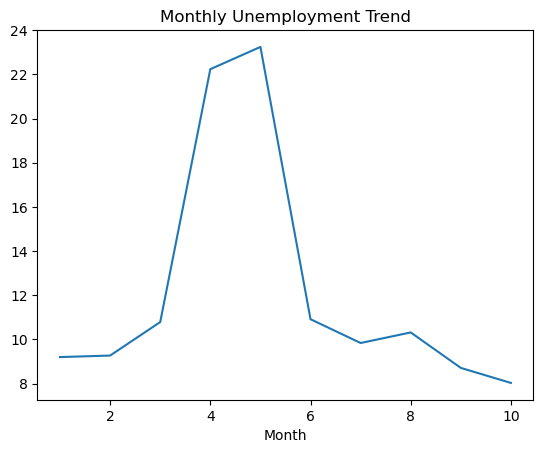

In [35]:
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_avg.plot(kind='line', title='Monthly Unemployment Trend')


### Policy Insights

The analysis shows that unemployment increased significantly during the Covid-19 period.
This suggests that government policies such as employment support programs, skill development
initiatives and financial assistance to small businesses are important to reduce the impact
of economic shocks on workers.
